# JADES DR3: matching NIRCam photometry to NIRSpec redshifts

**Goal:** produce an auditable nine-band photometry table with secure spectroscopic-redshift labels for the next ML case study.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SUMMARY_PATH = PROJECT_ROOT / 'outputs' / 'metrics' / 'match_summary.json'
MATCHED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'jades_dr3_goodsn_phot_spec_matched_all.csv'
ML_PATH = PROJECT_ROOT / 'data' / 'processed' / 'jades_dr3_goodsn_ml_ready.csv'

D:\Anaconda\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\Anaconda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


## Reproducible pipeline

The DR3 implementation lives in `src/dr3/`; rerun it from the project root with `python -m src.dr3.run_matching`. The notebook only presents the evidence and outputs.

In [2]:
summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))
pd.Series(summary, name='value').to_frame()

,value
photometric_rows,85709.0
spectroscopic_rows,1561.0
spectroscopic_rows_with_positive_nircam_id,1456.0
unique_positive_nircam_ids,1453.0
duplicate_spectroscopic_rows_removed,3.0
matched_unique_sources,1451.0
exact_id_matches,1450.0
nearest_sky_fallback_matches,1.0
unmatched_unique_positive_ids,2.0
match_radius_arcsec,0.2


In [3]:
matched = pd.read_csv(MATCHED_PATH)
ml_ready = pd.read_csv(ML_PATH)
ml_ready[['phot_id', 'z_phot', 'z_spec', 'z_spec_quality', 'separation_arcsec', 'n_valid_filters']].head()

,phot_id,z_phot,z_spec,z_spec_quality,separation_arcsec,n_valid_filters
0,1000033,4.22,3.909444,A,0.0,9
1,1000058,2.38,2.442181,A,0.0,9
2,1000095,4.15,3.909191,A,0.0,9
3,1000110,4.12,4.064162,A,0.0,9
4,1000113,0.78,5.788500,A,0.0,9


## Match validation

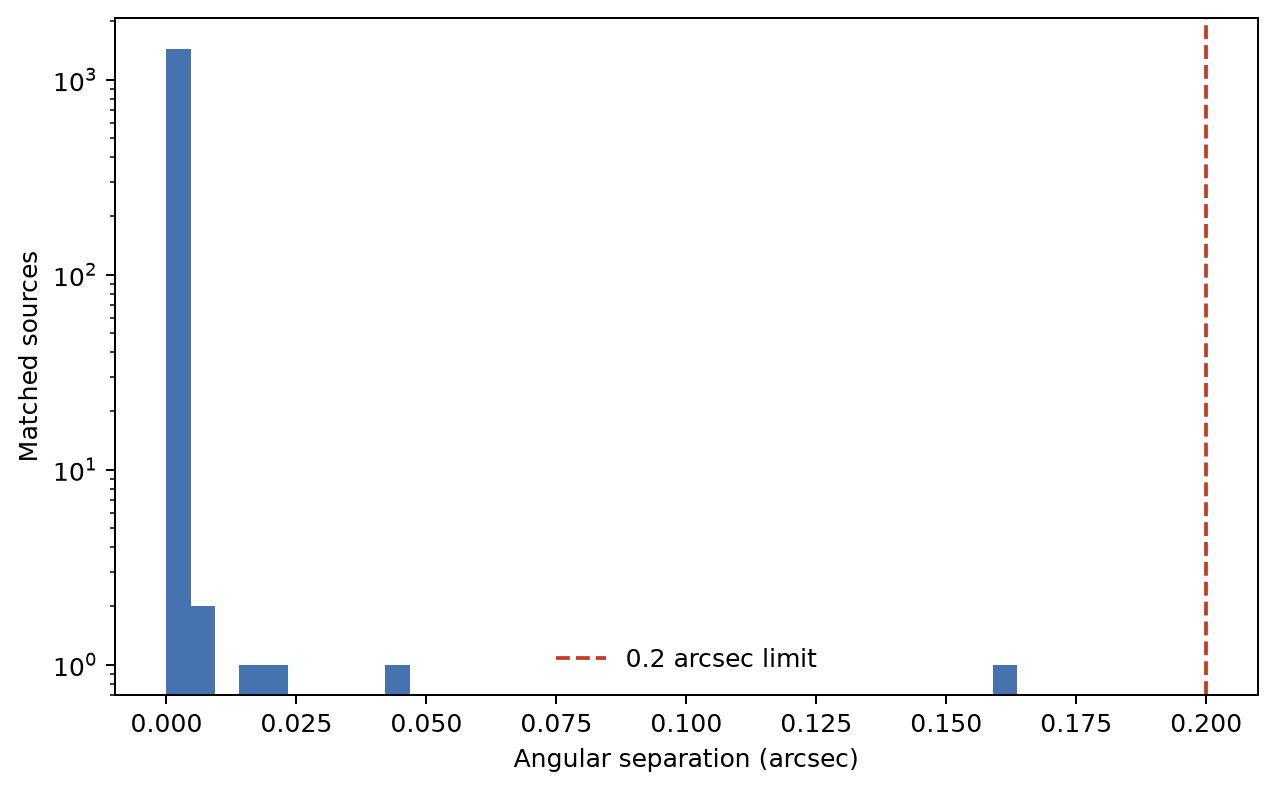

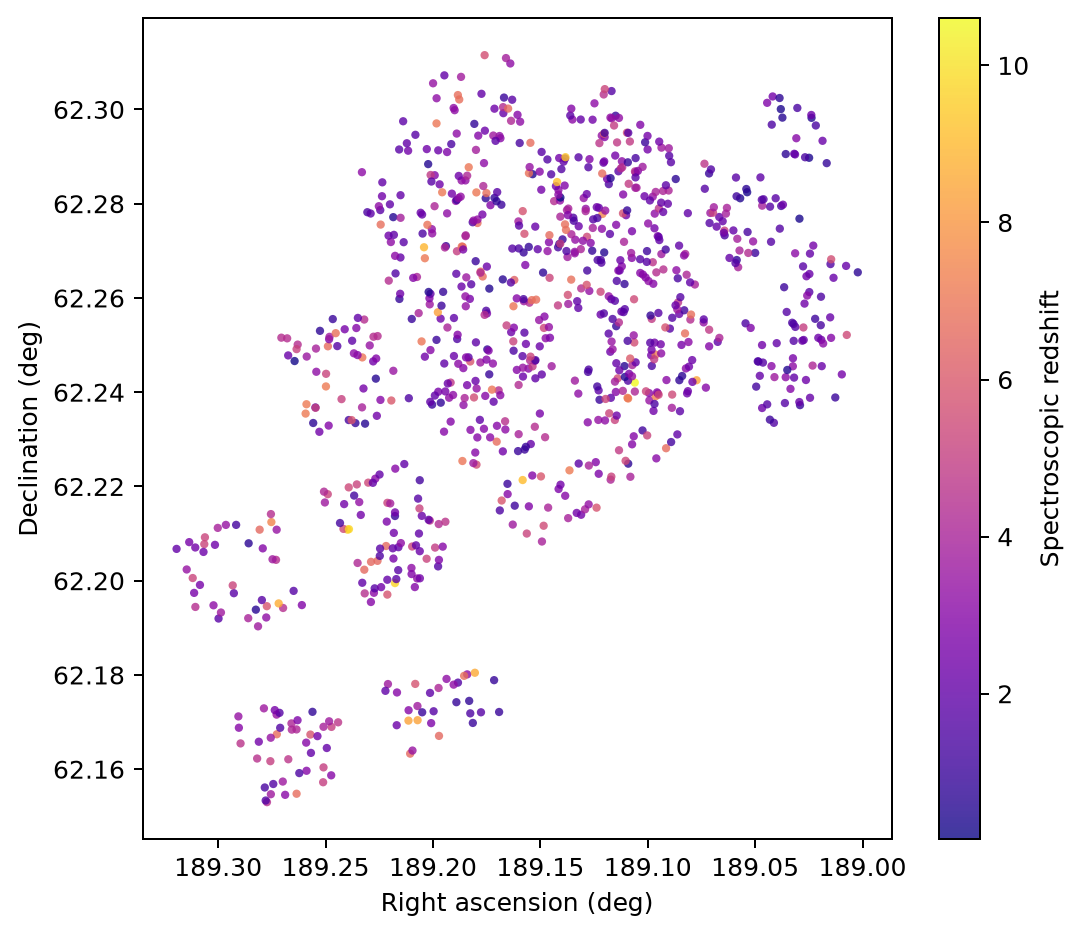

In [4]:
for filename in ['01_match_separation.png', '02_secure_sources_on_sky.png']:
    display(Image(filename=str(PROJECT_ROOT / 'outputs' / 'figures' / filename), width=700))

## Redshift benchmark and feature coverage

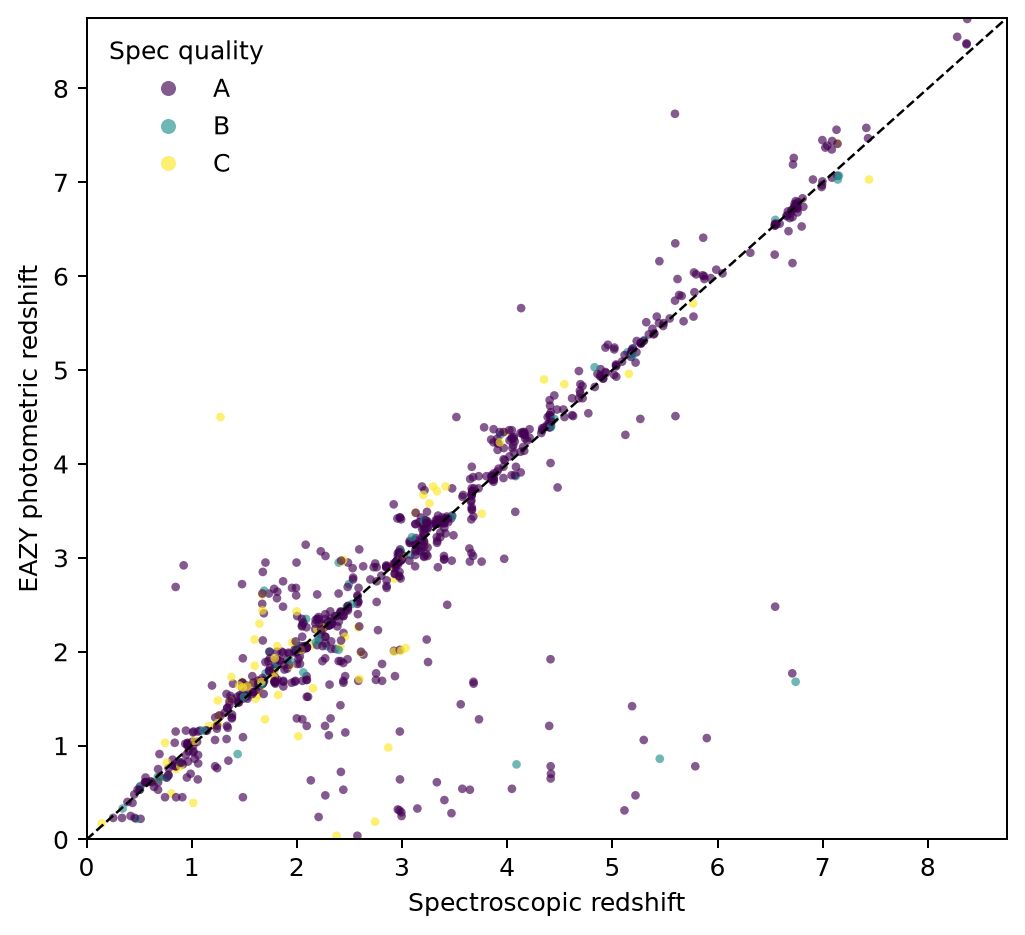

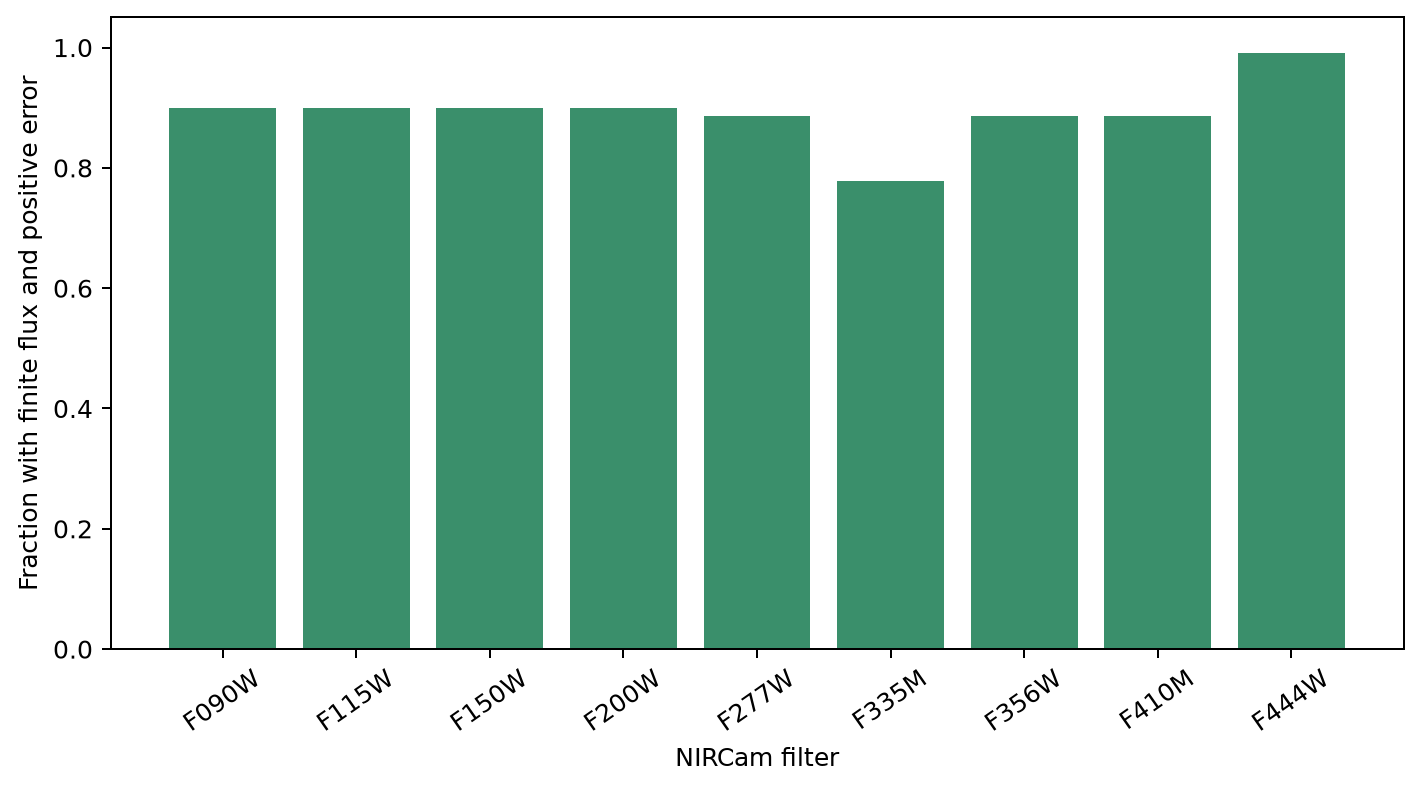

In [5]:
for filename in ['03_zphot_vs_zspec.png', '04_filter_coverage.png']:
    display(Image(filename=str(PROJECT_ROOT / 'outputs' / 'figures' / filename), width=700))

## Handoff

`jades_dr3_goodsn_ml_ready.csv` is the fixed input for the 8/23 baseline. The next task will predict `z_spec` from NIRCam fluxes and uncertainties, compare against `z_phot`, and keep the train/test protocol group-safe and reproducible.